In [1]:
# import Providentia
import providentia as prv

In [2]:
# magic to make plots appear inline
%matplotlib inline

# Initialise object

In [3]:
provi = prv.Providentia('trainings/20260722_Kuwait_Training_Dust_Modelling/kuwait.conf')

In [4]:
provi.print_config()

[TRAINING]
network = nasa-aeronet/directsun_v3-lev15
species = od550aero
resolution = 3hourly
start_date = 20250701
end_date = 20260101
model = osuite-global-000, a00k_cirrus-regional-000

    [[All]]

    [[Kuwait]]
    station_reference = Kuwait_University_2


# Load data

In [5]:
provi.load()


Updating file tree /home/avilanov/software/providentia/settings/internal/ghost_filetree_1.5.json...
Updating file tree /home/avilanov/software/providentia/settings/internal/nonghost_filetree.json...
Reading data

OBSERVATIONS
 - nasa-aeronet/directsun_v3-lev15|od550aero
MODELS
 - osuite-global-000
 - a00k_cirrus-regional-000
Resetting data filters to when class was initialised, loading TRAINING·All subsection filters.
Filtering data


# Save data to netCDF

In [6]:
provi.save(format='nc')

Data saved to /home/avilanov/software/providentia/saved_data/PRV_20260710_1019.nc


# Get data in memory

In [7]:
# return data in memory (in Xarray format)
data = provi.data(format='xr')
data

<xarray.Dataset> Size: 3MB
Dimensions:                                                      (
                                                                  data_label: 3,
                                                                  station_nasa-aeronet_directsun_v3-lev15|od550aero: 167,
                                                                  time: 1472,
                                                                  month: 6)
Coordinates:
  * time                                                         (time) datetime64[ns] 12kB ...
Dimensions without coordinates: data_label,
                                station_nasa-aeronet_directsun_v3-lev15|od550aero,
                                month
Data variables:
    data_labels                                                  (data_label) <U24 288B ...
    nasa-aeronet_directsun_v3-lev15|od550aero_data               (data_label, station_nasa-aeronet_directsun_v3-lev15|od550aero, time) float32 3MB ...
    nasa-aeronet_directsun_v3-lev15|od550aero_station_reference  (station_nasa-aeronet_directsun_v3-lev15|od550aero, month) <U19 76kB ...
    nasa-aeronet_directsun_v3-lev15|od550aero_longitude          (station_nasa-aeronet_directsun_v3-lev15|od550aero, month) float64 8kB ...
    nasa-aeronet_directsun_v3-lev15|od550aero_latitude           (station_nasa-aeronet_directsun_v3-lev15|od550aero, month) float64 8kB ...
    nasa-aeronet_directsun_v3-lev15|od550aero_station_name       (station_nasa-aeronet_directsun_v3-lev15|od550aero, month) <U19 76kB ...
Attributes:
    title:        Saved data from Providentia
    institution:  Barcelona Supercomputing Center
    source:       Providentia

# Make plots

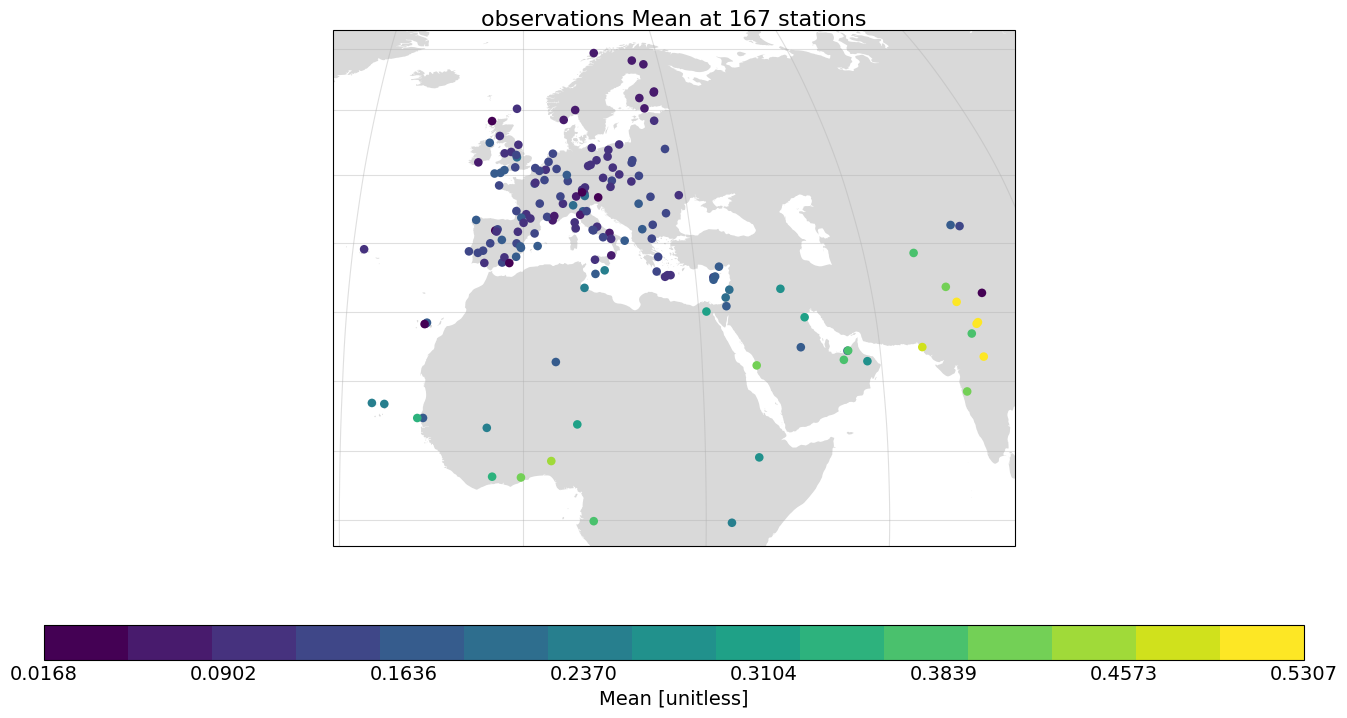

In [9]:
# make a map plot (mean of obs)
provi.plot('map-Mean', labela='observations')

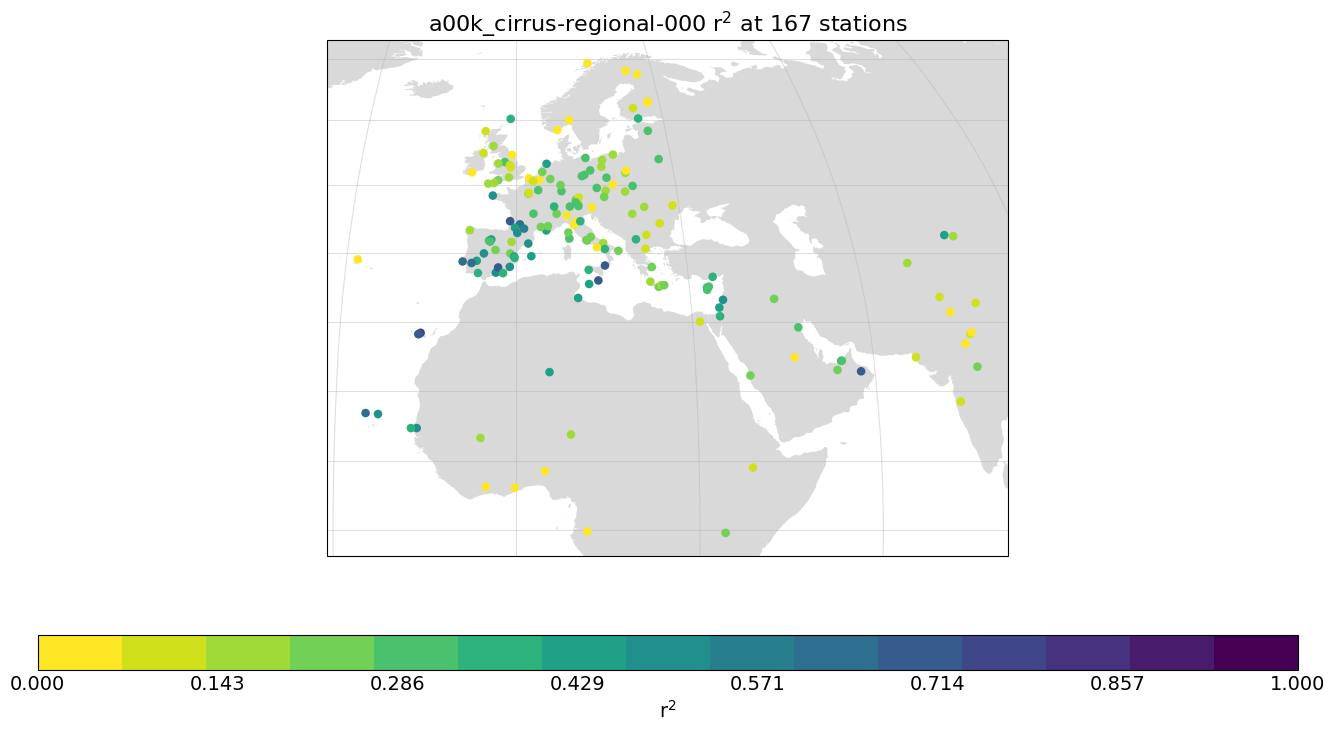

In [10]:
# make a map plot (r2 statistic)
provi.plot('map-r2', labela='observations', labelb='a00k_cirrus-regional-000')

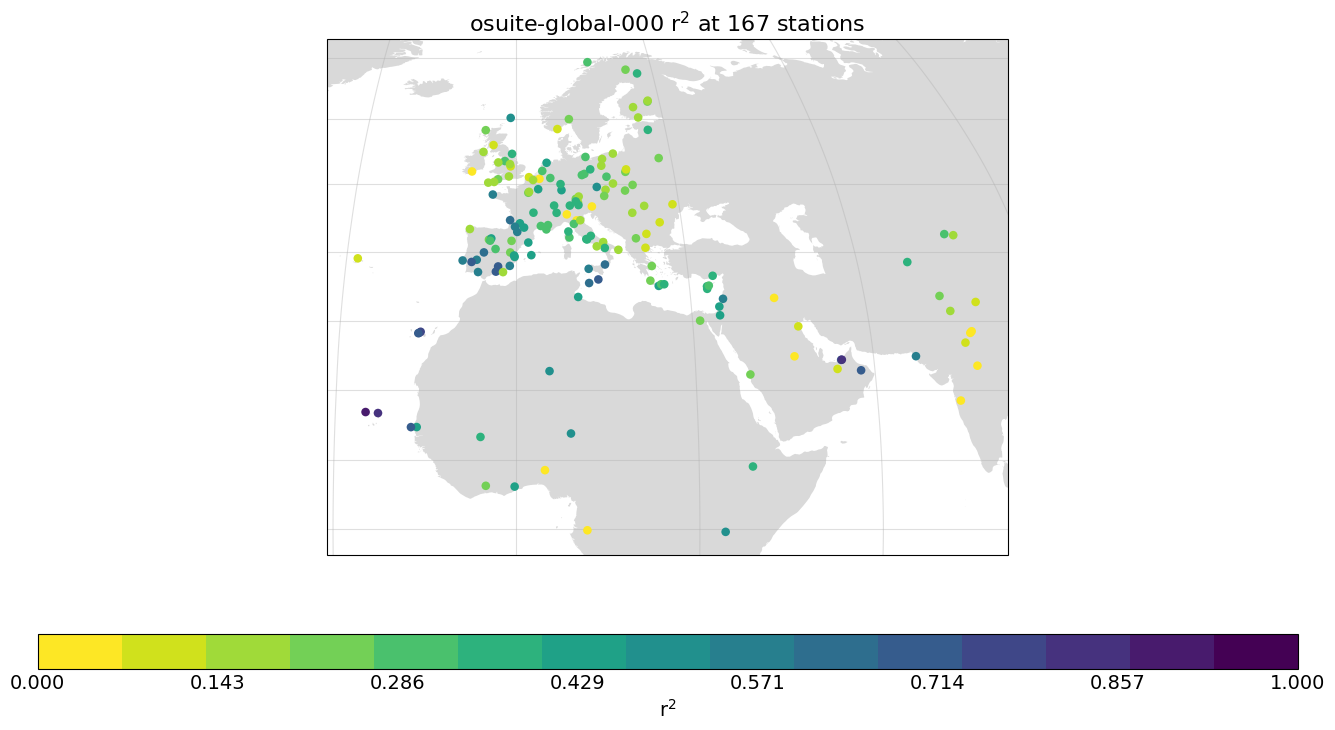

In [11]:
# make a map plot (r2 statistic)
provi.plot('map-r2', labela='observations', labelb='osuite-global-000')

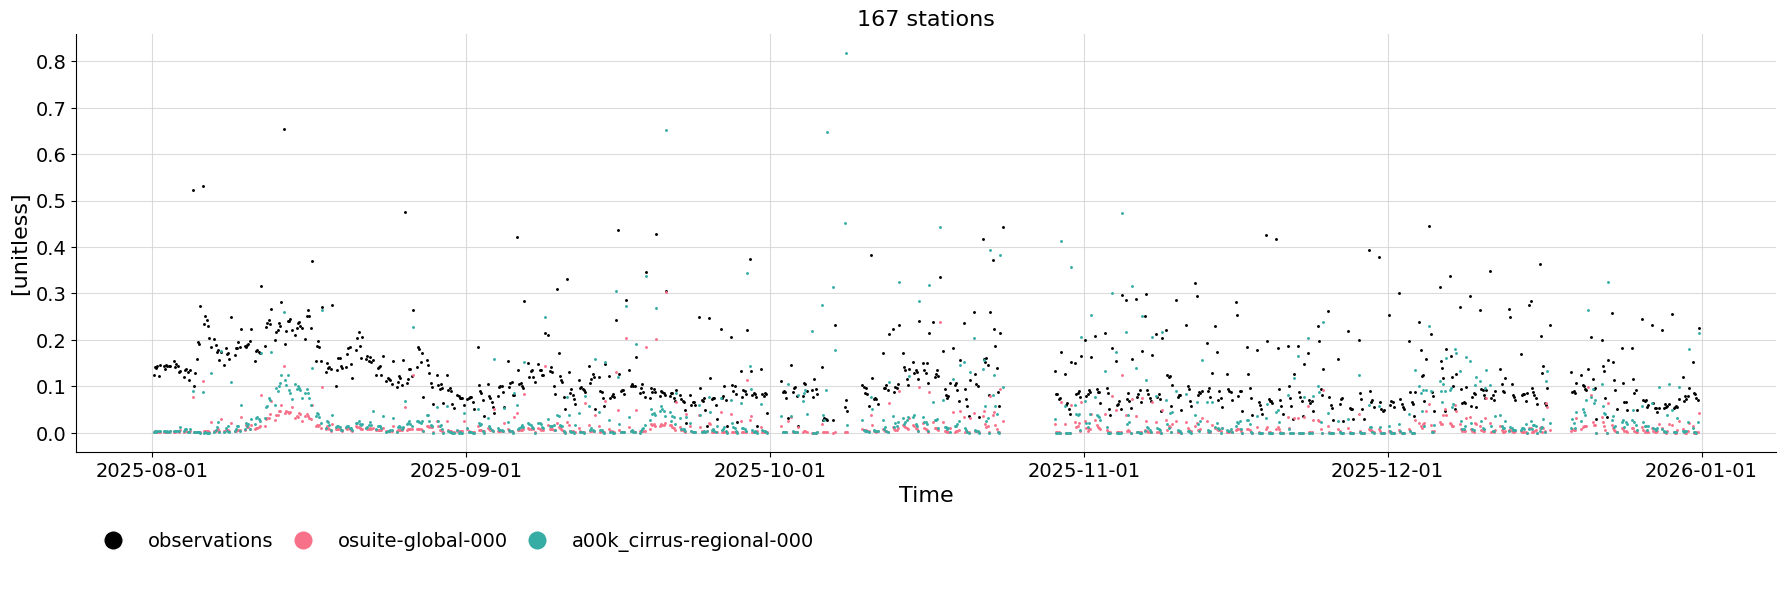

In [12]:
# make timeseries
provi.plot('timeseries')

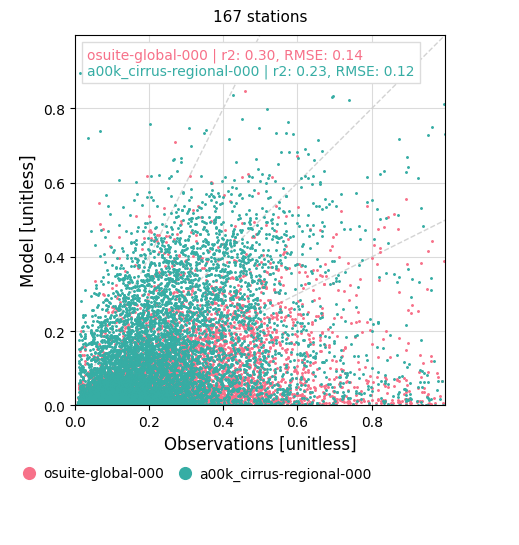

In [13]:
# make a scatter plot
provi.plot('scatter', annotate=True)

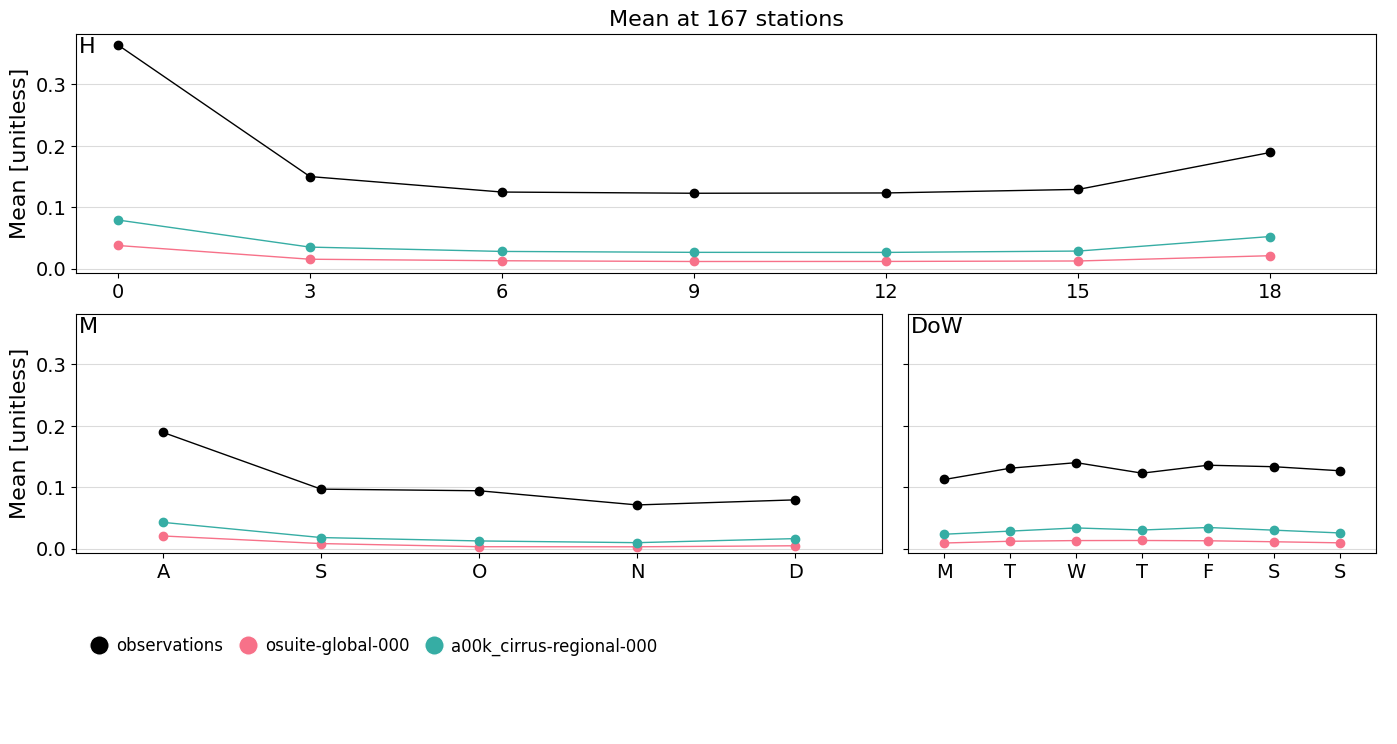

In [14]:
# make a periodic mean plot
provi.plot('periodic-Mean', threshold=True)

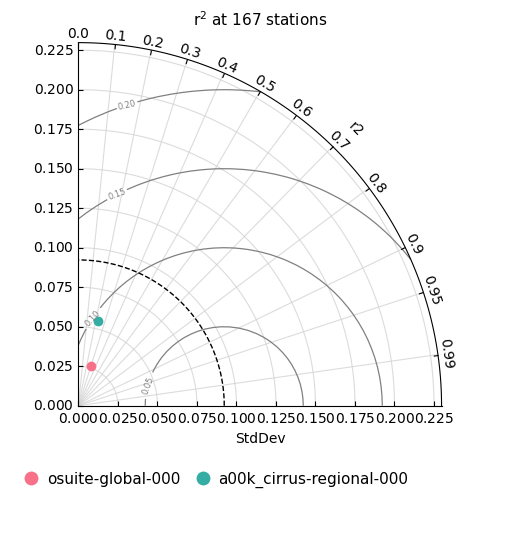

In [15]:
# make a Taylor diagram
provi.plot('taylor-r2')

Resetting data filters to when class was initialised, loading TRAINING·All subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading TRAINING·Kuwait subsection filters.
Filtering data
Resetting data filters to when class was initialised, loading TRAINING·All subsection filters.
Filtering data


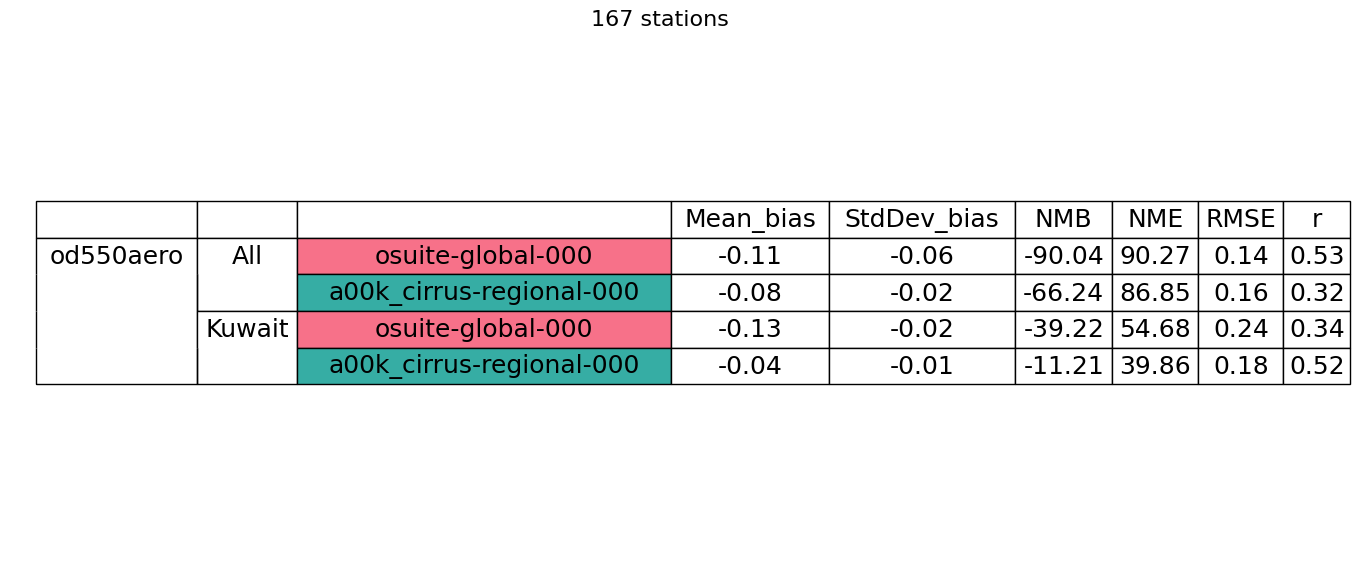

In [16]:
# make a statsummary plot
provi.plot('statsummary', multispecies=True, bias=True)

# Filter by station

In [17]:
# filter data by country metadata 
provi.reset()
provi.filter_station('Kuwait_University_2')
stations_data = provi.data(format='xr')
stations_data

Resetting all data filters.
Filtering data
Filtering data


<xarray.Dataset> Size: 31kB
Dimensions:                                                      (
                                                                  data_label: 3,
                                                                  station_nasa-aeronet_directsun_v3-lev15|od550aero: 1,
                                                                  time: 1472,
                                                                  month: 6)
Coordinates:
  * time                                                         (time) datetime64[ns] 12kB ...
Dimensions without coordinates: data_label,
                                station_nasa-aeronet_directsun_v3-lev15|od550aero,
                                month
Data variables:
    data_labels                                                  (data_label) <U24 288B ...
    nasa-aeronet_directsun_v3-lev15|od550aero_data               (data_label, station_nasa-aeronet_directsun_v3-lev15|od550aero, time) float32 18kB ...
    nasa-aeronet_directsun_v3-lev15|od550aero_station_reference  (station_nasa-aeronet_directsun_v3-lev15|od550aero, month) <U19 456B ...
    nasa-aeronet_directsun_v3-lev15|od550aero_longitude          (station_nasa-aeronet_directsun_v3-lev15|od550aero, month) float64 48B ...
    nasa-aeronet_directsun_v3-lev15|od550aero_latitude           (station_nasa-aeronet_directsun_v3-lev15|od550aero, month) float64 48B ...
    nasa-aeronet_directsun_v3-lev15|od550aero_station_name       (station_nasa-aeronet_directsun_v3-lev15|od550aero, month) <U19 456B ...
Attributes:
    title:        Saved data from Providentia
    institution:  Barcelona Supercomputing Center
    source:       Providentia

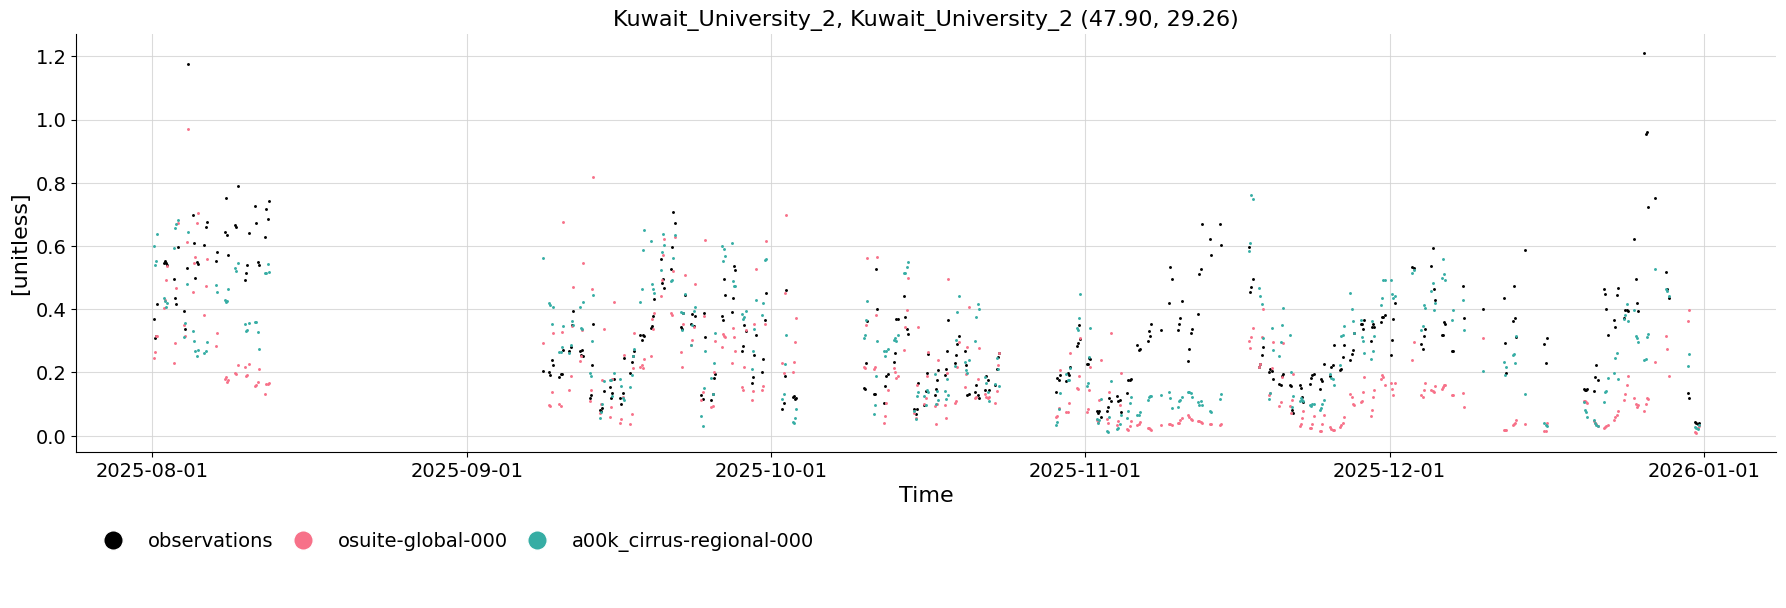

In [18]:
# make timeseries
provi.plot('timeseries')